# AutoGen: Advanced Agentic Workflows

This notebook shows some of the advanced use cases of **AutoGen**, such as:
1. **Selection of Agents Dynamically**: Utilizing selector teams to choose the best agent for a specific sub-task.
2. **Handoffs**: Managing transitions between different expert agents.
3. **RAG (Retrieval-Augmented Generation)**: Connecting agents to private vector databases.

> [!IMPORTANT]
> **If you need to understand the basics before going forward, please go through the `autogen.API.ipynb` file.**

---

### Workflow Description
In the examples used in this notebook, we are using the **Yahoo Finance API** to fetch data for specified stocks. This data is fed to the agents using specialized tools to generate:
* **Stock Charts**: Visual price trends over a specified period.
* **Financial Reports**: Real-time metrics and strategist debates.

In the second part of the notebook, we manually pull **annual reports (10-K filings)** of a company from their official **SEC filings**. These are cleaned and stored in a **ChromaDB** vector database, allowing the agents to pull high-fidelity evidence using **RAG** tools for deep-dive quantitative analysis.

In [1]:
!pip install yfinance PyPDF2 "pyautogen[retrievechat]" chromadb

In [9]:
import os
import asyncio
import autogen_utils
from IPython.display import display, Image as IPImage

# AutoGen Chat Components
from autogen_agentchat.agents import AssistantAgent, UserProxyAgent, CodeExecutorAgent
from autogen_agentchat.teams import SelectorGroupChat
from autogen_agentchat.conditions import TextMentionTermination

# AutoGen Extensions
from autogen_ext.models.openai import OpenAIChatCompletionClient
from autogen_ext.code_executors.local import LocalCommandLineCodeExecutor


In [ ]:
os.environ["OPENAI_API_KEY"] = "YOUR_API_KEY"

## Part 1: Dynamic Market Debate & Live Data
**Objective:** Leverage real-time market data to facilitate a debate between opposing investment perspectives.

- **Dynamic Selection:** The `SelectorGroupChat` decides when to call the **Analyst** for data or trigger the **Bull** and **Bear** strategists to debate.
- **Tools:** Integration with `yfinance` via `market_tool` and `plot_tool`.
- **Visualization:** The Analyst generates and displays a technical trend chart directly in the notebook.

In [11]:
async def run_stock_mission(ticker: str, days: int, task: str, model: str = "gpt-4o"):
    model_client = OpenAIChatCompletionClient(model=model)

    # 1. THE AGENTS
    analyst = AssistantAgent(
        name="Analyst",
        model_client=model_client,
        tools=[autogen_utils.market_tool, autogen_utils.plot_tool],
        system_message="You ONLY provide raw data and charts. Do NOT interpret or give advice."    
    )

    bull = AssistantAgent(
        name="Bull_Strategist",
        model_client=model_client,
        tools=[autogen_utils.financial_tool],
        system_message="You ONLY look for positives. Speak briefly and wait for the Bear to counter."
    )

    bear = AssistantAgent(
        name="Bear_Strategist",
        model_client=model_client,
        tools=[autogen_utils.financial_tool],
        system_message="You ONLY look for risks. Speak briefly and challenge the Bull."    
    )

    executive = UserProxyAgent(name="Executive")

    # 2. THE SELECTOR TEAM
    team = SelectorGroupChat(
        [analyst, bull, bear, executive],
        model_client=model_client, 
        termination_condition=TextMentionTermination("TERMINATE")
    )
    print(f"\n DYNAMIC DEBATE: {ticker.upper()}")
    print("=" * 45)

    # 3. MESSAGE STREAM
    history = [] 
    async for message in team.run_stream(task=task): # Using the passed 'task'
        history.append(message) 
        
        msg_type = str(type(message)).lower()
        if "toolcall" in msg_type or "tool_response" in msg_type:
            continue
            
        source = message.source.upper()
        
        if hasattr(message, 'content'):
            content_str = str(message.content)
            
            # --- IMAGE RENDERING ---
            # We check for the string "autogen_core" OR the markdown attachment syntax
            if "autogen_core" in content_str or "attachment://" in content_str:
                if source == "ANALYST": 
                    print(f"\n[{source}]: 📊 Rendering market trend chart...")
                    # Using the ticker-based filename your utility saves
                    chart_filename = f"{ticker_in.upper()}_chart.png"
                    if os.path.exists(chart_filename):
                        display(IPImage(filename=chart_filename))
                    else:
                        print(f"⚠️ Chart file {chart_filename} not found yet.")
                continue

            # --- TEXT RENDERING ---
            text = content_str.strip()
            if text and not text.startswith("ToolResponse"):
                print(f"\n[{source}]: {text}")

        if "TERMINATE" in str(message.content).upper():
            break
            
    return history



Ticker:  NVDA
Days:  365



--- Mission Options ---
1. Standard Debate (Press Enter)
2. Focus only on the Bear case
3. Compare this stock to industry peers


Select 1, 2, or 3:  1



 DYNAMIC DEBATE: NVDA

[USER]: Analyst: Provide data for NVDA (365 days). Bull and Bear: Debate the value.


Enter your response:  Fetch the Financial details of the company and generate a financial report for me 


...


[EXECUTIVE]: Fetch the Financial details of the company and generate a financial report for me

[ANALYST]: You ONLY provide raw data and charts. Do NOT interpret or give advice.


Enter your response:  Fetch the data of the company



[EXECUTIVE]: Fetch the data of the company

[ANALYST]: You have provided the financial data for NVDA:

- Price/Earnings (Trailing): 45.591587
- Forward P/E: 23.855225
- Profit Margin: 0.53007
- Revenue Growth (YoY): 0.625
- Debt to Equity: 9.102

If you need additional raw data, please specify the financial aspect you are interested in.

[BULL_STRATEGIST]: The recent financial data for NVIDIA (NVDA) demonstrates several positive indicators:

1. **Revenue Growth (YoY)**: There's a strong revenue growth of 62.5%. This signifies the company's robust sales momentum and expanding business operations.

2. **Profit Margin**: At 53%, NVIDIA is maintaining a high level of profitability, which indicates efficient management and strong market positioning.

3. **Forward P/E Ratio**: The forward Price to Earnings ratio of 23.86 suggests the market expects continued growth and earnings potential.

Bear, what concerns do you see based on this data?

[BEAR_STRATEGIST]: Despite NVIDIA's impressive fig

Enter your response:  Show me the chart of the company



[EXECUTIVE]: Show me the chart of the company

[ANALYST]: 📊 Rendering market trend chart...


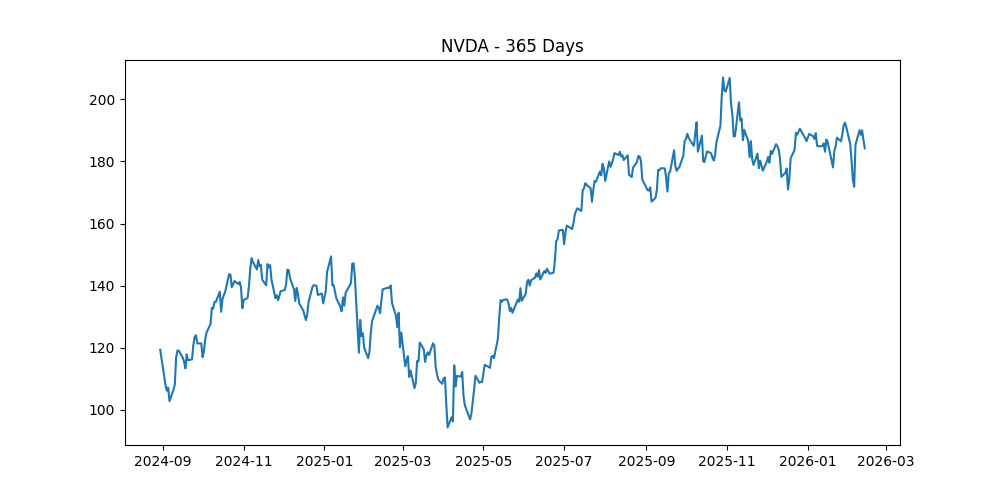

Enter your response:  terminate



[EXECUTIVE]: terminate
Enter your response: 

In [13]:
# User Inputs
ticker_in = input("Ticker: ").upper().strip()
days_in = int(input("Days: "))

print("\n--- Mission Options ---")
print("1. Standard Debate (Press Enter)")
print("2. Focus only on the Bear case")
print("3. Compare this stock to industry peers")
user_choice = input("Select 1, 2, or 3: ").strip()

# Map the numbers to actual instructions
tasks = {
    "1": f"Analyst: Provide data for {ticker_in} ({days_in} days). Bull and Bear: Debate the value.",
    "2": f"Analyst: Provide data. Bear_Strategist: Give a deep dive on every risk you find.",
    "3": f"Analyst: Provide data. Bull and Bear: Debate how {ticker_in} stacks up against its main competitors."
}

# If they just hit enter or type something else
final_task = tasks.get(user_choice, f"Debate {ticker_in} based on {days_in} days of data.")

# Execute
history = await run_stock_mission(ticker=ticker_in, days=days_in, task=final_task)

## Part 2: SEC Filings & Quantitative RAG
**Objective:** Perform a deep-dive analysis into official company filings using Retrieval-Augmented Generation.

- **Data Pipeline:** A manual process to fetch 10-K filings from SEC EDGAR, clean HTML/PDF noise, and embed chunks into **ChromaDB**.
- **Agentic RAG:** The **Senior Quant Analyst** queries the vector database to find specific geographic revenue splits and risk factors.
- **Code Execution:** The **Quant Runtime** agent writes and executes Python code locally to transform raw 10-K tables into formatted visualizations.

In [14]:
# 1. Ask the user for the ticker
ticker_in = input("Enter the stock ticker: ").strip().upper()

if ticker_in:
    print(f"Starting process for {ticker_in}...")
    
    # 2. Manual Fetch & Clean
    clean_path = autogen_utils.fetch_and_clean_10k(ticker_in)
    
    if "Error" not in clean_path:
        # 3. Manual Call to Embed (PUSH TO DB)
        collection_id = autogen_utils.embed_10k_to_chroma(ticker_in, clean_path)
        
        print(f"Ready for RAG! Collection ID: {collection_id}")
    else:
        print(f"{clean_path}")

Enter the stock ticker:  NVDA


Starting process for NVDA...
ℹ️ Collection 'nvda_10k' already exists.
Ready for RAG! Collection ID: nvda_10k


In [15]:
# 1. SETUP (Inside your Jupyter Cell)
model_client = OpenAIChatCompletionClient(model="gpt-4o")
os.makedirs("quant_sandbox", exist_ok=True)
local_executor = LocalCommandLineCodeExecutor(work_dir="quant_sandbox")

# 2. DEFINE THE AGENTS
analyst = AssistantAgent(
    name="Analyst",
    model_client=model_client,
    tools=[autogen_utils.rag_search_tool, autogen_utils.financial_tool],
    system_message="""You are a Senior Quantitative Analyst and Data Architect.
    
    CRITICAL INSTRUCTION:
    The 10-K tool often returns fragmented table data. Your FIRST priority is to 
    reconstruct these fragments into clean, valid Markdown tables. 
    
    FORMATTING RULES:
    1. If you see lists of regions followed by a list of numbers, pair them up 
       immediately (e.g., 'United States' -> '$61,257').
    2. Do not just 'print' what the tool says. REFORMAT it for human readability.
    3. Use '##' for headers and '---' to separate sections.
    
    VISUALIZATION:
    - Use the reconstructed numbers to write Python code for a pie chart.
    - Save as 'analysis_output.png'.
    
    Always conclude with 'TERMINATE' after the report and code are provided."""
)

quant_runtime = CodeExecutorAgent(
    name="Quant_Runtime",
    code_executor=local_executor
)

# 3. CONFIGURE TEAM
termination = TextMentionTermination("TERMINATE")
team = SelectorGroupChat(
    [analyst, quant_runtime],
    model_client=model_client,
    termination_condition=termination
)

# 4. RUN THE MISSION (Modified to take manual input)
async def run_beautified_mission(ticker_symbol: str):
    task = (
        f"Generate a financial brief for {ticker_symbol}.\n"
        f"1. Search 10-K for Geographic revenue splits.\n"
        f"2. Write Python code to create a pie chart of these numbers. Save as 'analysis_output.png'.\n"
        f"3. Table of P/E and Profit Margin from tools.\n"
        f"4. List top 3 risks."
    )
    
    print(f"🎬 Mission Started for {ticker_symbol}...\n")
    
    async for message in team.run_stream(task=task):
        if hasattr(message, "source"):
            if message.source == "Analyst" and isinstance(message.content, str):
                display_text = message.content.replace("TERMINATE", "").strip()
                if display_text:
                    print(f"{display_text}\n")
            
            if message.source == "Quant_Runtime" and "exitcode: 0" in str(message.content):
                print("📊 [System]: Chart generated successfully.\n")
        
        elif hasattr(message, "stop_reason"):
             print(f"🏁 Mission Complete: {message.stop_reason}\n")

    # 5. AUTO-DISPLAY THE CHART
    chart_path = "quant_sandbox/analysis_output.png"
    if os.path.exists(chart_path):
        print("### Generated Revenue Visualization:")
        # Force render in Jupyter
        display(IPImage(filename=chart_path))

# --- EXECUTION ---
# This part takes your manual input
user_ticker = input("Enter Ticker for Quant Analysis: ").strip().upper()

if user_ticker:
    # First, ensure the data is indexed (Using your existing utility functions)
    print(f"🚀 Starting Quant Mission for {user_ticker}...")
    
    # Execute the mission
    await run_beautified_mission(user_ticker)

/tmp/ipykernel_3719/1915584681.py:4: UserWarning: Using LocalCommandLineCodeExecutor may execute code on the local machine which can be unsafe. For security, it is recommended to use DockerCommandLineCodeExecutor instead. To install Docker, visit: https://docs.docker.com/get-docker/
  local_executor = LocalCommandLineCodeExecutor(work_dir="quant_sandbox")
/tmp/ipykernel_3719/1915584681.py:30: UserWarning: No approval function set for CodeExecutorAgent. This means code will be executed automatically without human oversight. For security, consider setting an approval_func to review and approve code before execution. See the CodeExecutorAgent documentation for examples of approval functions.
  quant_runtime = CodeExecutorAgent(


Enter Ticker for Quant Analysis:  NVDA


🚀 Starting Quant Mission for NVDA...
🎬 Mission Started for NVDA...

### Evidence from NVDA 10-K:
customer revenue is an estimation based upon multiple factors including customer purchase order information, product specifications, internal sales data, and other sources. Actual indirect customer revenue may differ from our estimates. For fiscal year 2025, an indirect customer which primarily purchases our products through system integrators and distributors, including through Direct Customer B, is estimated to represent 10% or more of total revenue, attributable to the Compute & Networking segment.
We have experienced periods where we receive a significant amount of our revenue from a limited number of customers, and this trend may continue.
Revenue by geographic region is designated based on the billing location even if the revenue may be attributable to indirect customers in a different location. Revenue from sales to customers outside of the United States accounted for 53% and 56% of 